In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

In [3]:
df = pd.read_csv("/content/dataset_for_SI.csv")
df.head(10)

,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,...,0,0,0,0,0,0,0,0,3,0
1,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,...,0,0,0,0,0,0,0,0,3,0
2,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,...,0,0,0,0,0,0,0,0,3,0
3,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,...,0,0,0,0,0,0,0,0,0,0
4,2.000000,5.758408,5.758408,0.278083,0.278083,0.711012,28.600000,332.491,304.267,332.225249,...,0,0,0,0,0,0,0,0,0,0
5,0.770000,2.584472,2.584472,0.429649,0.429649,0.328539,36.564103,528.869,472.421,528.443253,...,0,0,0,0,0,0,0,0,0,0
6,0.820000,13.821880,13.821880,0.079845,-0.301260,0.217332,31.333333,695.089,624.529,694.543729,...,0,0,0,0,0,0,0,0,4,0
7,3.070681,14.171614,14.171614,0.019123,-0.411828,0.187781,29.157895,763.123,696.595,762.512429,...,0,0,0,0,0,0,0,0,0,0
8,7.857143,5.856558,5.856558,0.246833,0.246833,0.701837,28.440000,334.463,308.255,334.204513,...,0,0,0,0,0,0,0,0,0,0
9,1.664336,2.589342,2.589342,0.380221,0.380221,0.640283,33.250000,328.564,290.260,328.299877,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Разделение на признаки и целевую переменную
X = df.drop('SI', axis=1)
y = df['SI']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Вычисление медианы на трейне
median_si = y_train.median()

# Перевод в бинарную задачу
y_train_binary = (y_train > median_si).astype(int)
y_test_binary = (y_test > median_si).astype(int)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Напишем функция для обучения и оценки модели

In [7]:
def evaluate_classifiers(models, X_train, y_train, X_test, y_test):
    results = []

    for name, model in models.items():
        # Обучение с кросс-валидацией
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        acc_cv = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv).mean()
        prec_cv = cross_val_score(model, X_train, y_train, scoring='precision', cv=cv).mean()
        rec_cv = cross_val_score(model, X_train, y_train, scoring='recall', cv=cv).mean()
        f1_cv = cross_val_score(model, X_train, y_train, scoring='f1', cv=cv).mean()

        # Точность на тесте
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc_test = accuracy_score(y_test, y_pred)
        prec_test = precision_score(y_test, y_pred)
        rec_test = recall_score(y_test, y_pred)
        f1_test = f1_score(y_test, y_pred)

        results.append({
            'Model': name,
            'CV Accuracy': acc_cv,
            'CV Precision': prec_cv,
            'CV Recall': rec_cv,
            'CV F1': f1_cv,
            'Test Accuracy': acc_test,
            'Test Precision': prec_test,
            'Test Recall': rec_test,
            'Test F1': f1_test
        })

    return results

Подготовим список моделей

In [8]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=200, verbose=0)
}

In [10]:
results =  evaluate_classifiers(models, X_train_scaled, y_train_binary, X_test_scaled, y_test_binary)
results_df = pd.DataFrame(results)
results_df.sort_values(by='Test F1', ascending=False, inplace=True)
print(results_df.round(4))

                 Model  CV Accuracy  CV Precision  CV Recall   CV F1  \
1              XGBoost       0.5929        0.6002     0.5743  0.5827   
4             CatBoost       0.6000        0.6079     0.5857  0.5931   
2  Logistic Regression       0.5700        0.5728     0.5657  0.5664   
0        Random Forest       0.5986        0.6059     0.5886  0.5928   
3                  SVM       0.5871        0.5913     0.5943  0.5882   

   Test Accuracy  Test Precision  Test Recall  Test F1  
1         0.6761          0.6854       0.6778   0.6816  
4         0.6591          0.6596       0.6889   0.6739  
2         0.6591          0.6786       0.6333   0.6552  
0         0.6420          0.6517       0.6444   0.6480  
3         0.6193          0.6264       0.6333   0.6298  


/tmp/ipython-input-2223202745.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(data=results_df, x='Model', y=f'Test {metric}', palette="viridis", ax=ax)
/tmp/ipython-input-2223202745.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(data=results_df, x='Model', y=f'Test {metric}', palette="viridis", ax=ax)
/tmp/ipython-input-2223202745.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(data=results_df, x='Model', y=f'Test {metric}', palette="viridis", ax=ax)
/tmp/ipython-input-2223202745.py:8: FutureWarning: 

Passing `palet

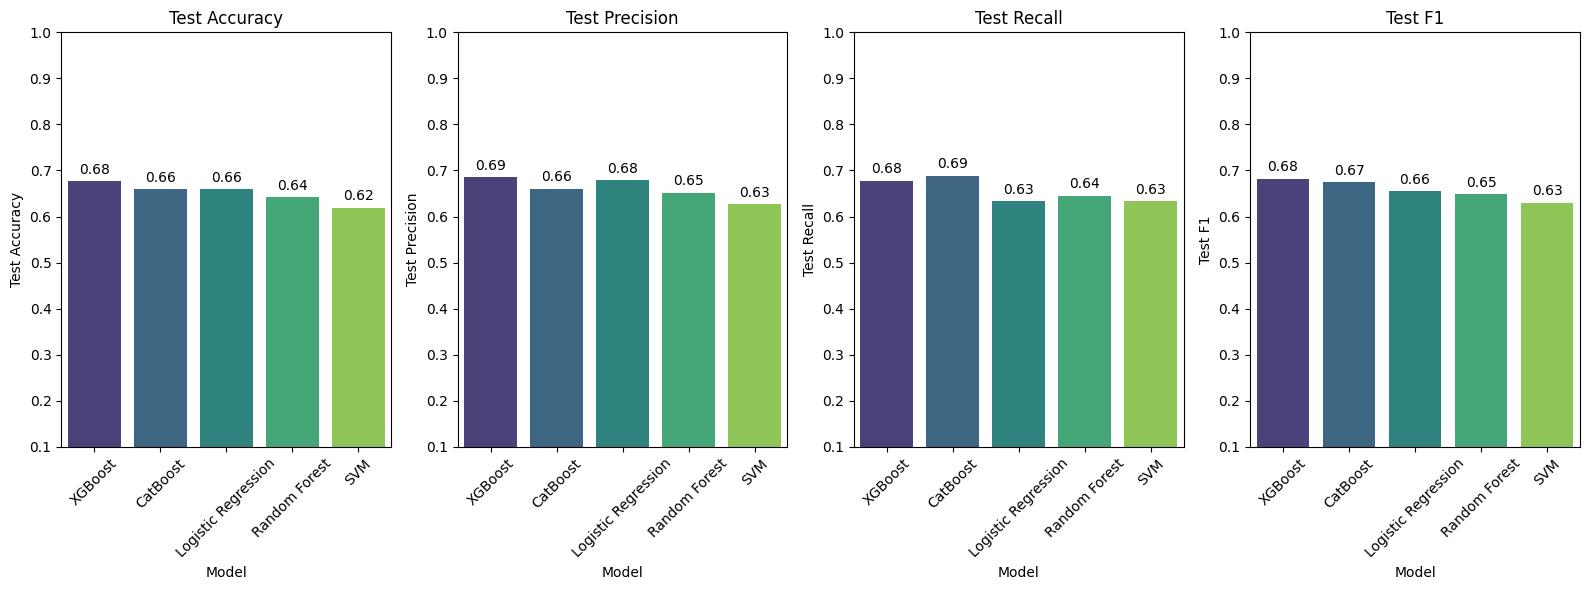

In [12]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

fig, axes = plt.subplots(1, 4, figsize=(16, 6))


for idx, metric in enumerate(metrics):
    ax = axes[idx]
    g = sns.barplot(data=results_df, x='Model', y=f'Test {metric}', palette="viridis", ax=ax)
    ax.set_ylim(0.1, 1)
    ax.tick_params(axis='x', rotation=45)

    for patch in g.patches:
        height = patch.get_height()
        g.annotate(f'{height:.2f}',
                  xy=(patch.get_x() + patch.get_width() / 2, height + 0.01),
                  ha='center', va='bottom', fontsize=10)

    ax.set_title(f'Test {metric}')


plt.tight_layout()
plt.show()

XGBoost показала лучший результат по трем метрикам из четырех - попробуем его улучшить.

In [25]:
# Параметры для подбора
param_grid = {
    'C': [150, 200, 250],
    'tol': [0.05, 0.1, 0.2]
}

# Инициализация xgb
xgb_model = XGBClassifier(random_state=42, class_weight='balanced')

# GridSearchCV
grid_search = GridSearchCV(xgb_model, param_grid, cv=10, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train_binary)

# Лучшая модель
best_xgb = grid_search.best_estimator_
print("Лучшие параметры:", grid_search.best_params_)

Fitting 10 folds for each of 9 candidates, totalling 90 fits


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [20:04:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "C", "class_weight", "tol" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Лучшие параметры: {'C': 150, 'tol': 0.05}


In [26]:
y_pred = best_xgb.predict(X_test_scaled)
acc_test = accuracy_score(y_test_binary, y_pred)
prec_test = precision_score(y_test_binary, y_pred)
rec_test = recall_score(y_test_binary, y_pred)
f1_test = f1_score(y_test_binary, y_pred)
print(f'Test Accuracy: {acc_test}')
print(f'Test Precision: {prec_test}')
print(f'Test Recall: {rec_test}')
print(f'Test F1: {f1_test}')
results.append({
    'Model': 'XGB tuned',
    'CV Accuracy': None,
    'CV Precision': None,
    'CV Recall': None,
    'CV F1': None,
    'Test Accuracy': acc_test,
    'Test Precision': prec_test,
    'Test Recall': rec_test,
    'Test F1': f1_test
})

Test Accuracy: 0.6761363636363636
Test Precision: 0.6853932584269663
Test Recall: 0.6777777777777778
Test F1: 0.6815642458100558


Посмотрим на визуализацию

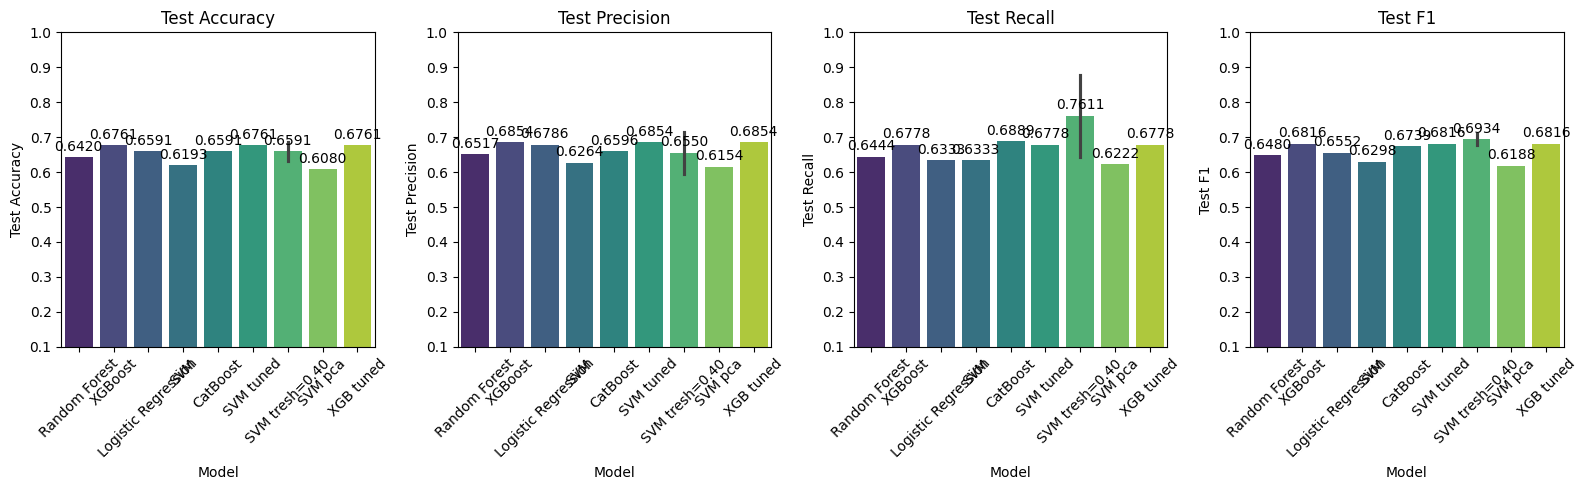

In [27]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(16, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    ax = sns.barplot(x='Model', y=f'Test {metric}', data=results_df, palette="viridis", hue='Model', legend=False)
    plt.title(f'Test {metric}')
    plt.ylim(0.1, 1)
    plt.xticks(rotation=45)

    # Добавление подписей значений
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Часть метрик стали хуже, часть стали лучше. Попробуем подобрать порог вероятности, максимизирующий F1

In [28]:
y_pred_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]
thresholds = np.linspace(0.1, 0.9, 100)
best_f1 = 0.0
best_threshold = 0.5

for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(y_test_binary, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Лучший порог: {best_threshold:.2f}, F1: {best_f1:.4f}")

Лучший порог: 0.12, F1: 0.7085


Добавим метрики такого варианта в результаты.

In [29]:
y_pred_12 = (y_pred_proba >= best_threshold).astype(int)

acc_test = accuracy_score(y_test_binary, y_pred_12)
prec_test = precision_score(y_test_binary, y_pred_12)
rec_test = recall_score(y_test_binary, y_pred_12)
f1_test = f1_score(y_test_binary, y_pred_12)
print(f'Test Accuracy: {acc_test}')
print(f'Test Precision: {prec_test}')
print(f'Test Recall: {rec_test}')
print(f'Test F1: {f1_test}')
results.append({
    'Model': 'XGB tresh=0.40',
    'CV Accuracy': None,
    'CV Precision': None,
    'CV Recall': None,
    'CV F1': None,
    'Test Accuracy': acc_test,
    'Test Precision': prec_test,
    'Test Recall': rec_test,
    'Test F1': f1_test
})

Test Accuracy: 0.6306818181818182
Test Precision: 0.5939849624060151
Test Recall: 0.8777777777777778
Test F1: 0.7085201793721974


Попробуем подобрать порог вероятности с помощью ROC.

In [30]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_proba)

# Выбираем порог, который максимизирует tpr - fpr (разделение классов)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Оптимальный порог по ROC:", optimal_threshold)

Оптимальный порог по ROC: 0.5996674


In [31]:
y_pred_59 = (y_pred_proba >= optimal_threshold).astype(int)

acc_test = accuracy_score(y_test_binary, y_pred_59)
prec_test = precision_score(y_test_binary, y_pred_59)
rec_test = recall_score(y_test_binary, y_pred_59)
f1_test = f1_score(y_test_binary, y_pred_59)
print(f'Test Accuracy: {acc_test}')
print(f'Test Precision: {prec_test}')
print(f'Test Recall: {rec_test}')
print(f'Test F1: {f1_test}')
results.append({
    'Model': 'XGB roc',
    'CV Accuracy': None,
    'CV Precision': None,
    'CV Recall': None,
    'CV F1': None,
    'Test Accuracy': acc_test,
    'Test Precision': prec_test,
    'Test Recall': rec_test,
    'Test F1': f1_test
})

Test Accuracy: 0.6875
Test Precision: 0.7160493827160493
Test Recall: 0.6444444444444445
Test F1: 0.6783625730994152


Визуализируем полученные результаты

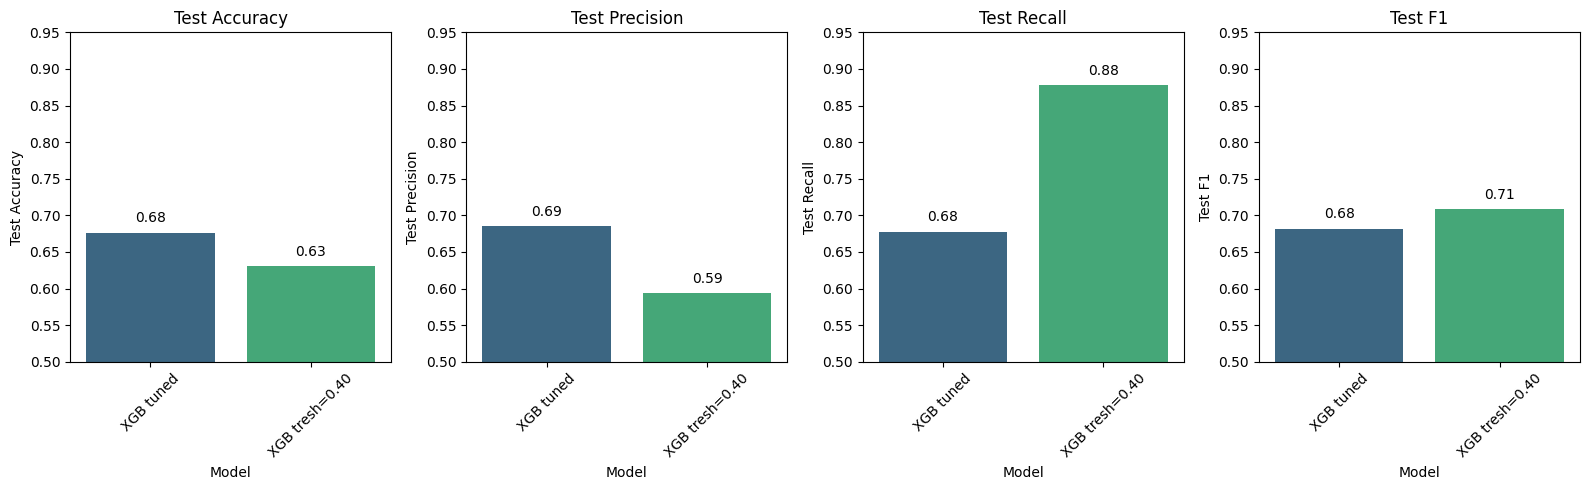

In [32]:
results_df = pd.DataFrame(results)
res_svm = results_df[results_df['Model'].isin(['XGB', 'XGB tuned', 'XGB tresh=0.40', 'XGB roc'])]

plt.figure(figsize=(16, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    ax = sns.barplot(x='Model', y=f'Test {metric}', data=res_svm, palette="viridis", hue='Model', legend=False)
    plt.title(f'Test {metric}')
    plt.ylim(0.5, 0.95)
    plt.xticks(rotation=45)

    # Добавление подписей значений
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()